# Week 1 — Olist Data Understanding, ER Mapping and Audit

## Project Objective

Week 1 establishes the foundation for the Customer Lifetime Value & Segmentation Engine by developing a thorough understanding of the raw Olist data before any modeling work begins. Specifically, this notebook covers:

- The **structure of all 9 Olist tables** (rows, columns, data types)
- The **key relationships** between tables (`order_id`, `customer_id`, `customer_unique_id`, `product_id`, `seller_id`, `review_id`, ZIP-code prefixes)
- Initial **data-quality understanding**, including a first pass at verified vs. inferred keys
- **Review-score analysis** and **delivery-delay analysis** (audit portion — performed in the next step of this notebook)
- The **foundation for later work**: RFM analysis, CLV modeling, and Tableau dashboarding

This step focuses only on **data loading and table profiling**. No RFM, CLV, segmentation, or dashboard work is performed here, and the raw files in `data/raw/` are treated as read-only.

## 1. Environment Setup

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Environment setup successful!")

Python: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:30:20) [Clang 20.1.8 ]
Pandas: 3.0.3
Environment setup successful!


## 2. Data Loading — All 9 Olist Tables

Each of the 9 raw Olist CSV files in `data/raw/` is loaded, unmodified, into a dictionary called `dfs` keyed by a short logical name. The original files are only read, never written to.

In [2]:
from pathlib import Path
from IPython.display import display

RAW_DATA_DIR = Path("../data/raw")

file_map = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

dfs = {}
for name, filename in file_map.items():
    filepath = RAW_DATA_DIR / filename
    dfs[name] = pd.read_csv(filepath)
    print(f"Loaded '{name}': {dfs[name].shape[0]:>7,} rows x {dfs[name].shape[1]:>2} columns  <- {filename}")

assert len(dfs) == 9, f"Expected 9 tables, loaded {len(dfs)}"
print(f"\nAll {len(dfs)} Olist tables loaded successfully into `dfs`.")

Loaded 'customers':  99,441 rows x  5 columns  <- olist_customers_dataset.csv


Loaded 'geolocation': 1,000,163 rows x  5 columns  <- olist_geolocation_dataset.csv
Loaded 'order_items': 112,650 rows x  7 columns  <- olist_order_items_dataset.csv
Loaded 'payments': 103,886 rows x  5 columns  <- olist_order_payments_dataset.csv


Loaded 'reviews':  99,224 rows x  7 columns  <- olist_order_reviews_dataset.csv
Loaded 'orders':  99,441 rows x  8 columns  <- olist_orders_dataset.csv
Loaded 'products':  32,951 rows x  9 columns  <- olist_products_dataset.csv
Loaded 'sellers':   3,095 rows x  4 columns  <- olist_sellers_dataset.csv
Loaded 'category_translation':      71 rows x  2 columns  <- product_category_name_translation.csv

All 9 Olist tables loaded successfully into `dfs`.


## 3. Dataset Overview

A summary of row and column counts for every loaded table.

In [3]:
overview = pd.DataFrame(
    [
        {"table": name, "row_count": df.shape[0], "column_count": df.shape[1]}
        for name, df in dfs.items()
    ]
).sort_values("table").reset_index(drop=True)

display(overview)

,table,row_count,column_count
0,category_translation,71,2
1,customers,99441,5
2,geolocation,1000163,5
3,order_items,112650,7
4,orders,99441,8
5,payments,103886,5
6,products,32951,9
7,reviews,99224,7
8,sellers,3095,4


## 4. Table Columns

Column names for every table, so the full schema is visible at a glance.

In [4]:
for name, df in dfs.items():
    print(f"\n{name}  ({df.shape[1]} columns)")
    print("-" * (len(name) + 14))
    print(list(df.columns))


customers  (5 columns)
-----------------------
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

geolocation  (5 columns)
-------------------------
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

order_items  (7 columns)
-------------------------
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

payments  (5 columns)
----------------------
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews  (7 columns)
---------------------
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

orders  (8 columns)
--------------------
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'orde

## 5. Data Types

Pandas-inferred data types for every column of every table (dtype inference only — no cleaning or casting performed).

In [5]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    display(df.dtypes.rename("dtype").to_frame())


--- customers ---


,dtype
customer_id,str
customer_unique_id,str
customer_zip_code_prefix,int64
customer_city,str
customer_state,str



--- geolocation ---


,dtype
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,str
geolocation_state,str



--- order_items ---


...

,dtype
product_id,str
product_category_name,str
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64



--- sellers ---


,dtype
seller_id,str
seller_zip_code_prefix,int64
seller_city,str
seller_state,str



--- category_translation ---


,dtype
product_category_name,str
product_category_name_english,str


## 6. Table Descriptions

Purpose of each of the 9 loaded tables:

| Table | Purpose |
|---|---|
| `customers` | One row per order-level customer record; contains an order-scoped `customer_id`, the persistent `customer_unique_id` for the underlying person/account, and customer location (city, state, ZIP prefix). |
| `geolocation` | Lookup table mapping Brazilian ZIP-code prefixes to approximate latitude/longitude, city, and state. Multiple coordinate rows can exist per ZIP prefix. |
| `order_items` | Line-item detail for each order — one row per purchased item, including the linked product, seller, price, freight value, and shipping deadline. |
| `payments` | Payment transaction detail per order, including payment type, number of installments, and payment value. An order may have multiple payment rows. |
| `reviews` | Customer review data per order, including the review score (1–5), free-text comments, and review/answer timestamps. |
| `orders` | Order header table — one row per order — with order status and the full timeline (purchase, approval, carrier handoff, delivery to customer, estimated delivery date). |
| `products` | Product catalog with category name, physical dimensions, and weight. |
| `sellers` | Seller master data, including seller location (city, state, ZIP prefix). |
| `category_translation` | Bridge/lookup table translating Portuguese product category names into English. |

## 7. Primary Key / Foreign Key Identification

Candidate keys are checked for row-level uniqueness below. A key is labeled **Verified** only when the uniqueness check confirms it; otherwise it is labeled **Inferred** (a relationship that is structurally plausible — matching column names/semantics — but not yet confirmed as a clean 1:1 or 1:many key, and in the case of `reviews`, flagged for the anomaly-audit step).

In [6]:
candidate_keys = {
    "customers": ["customer_id"],
    "geolocation": ["geolocation_zip_code_prefix"],
    "order_items": ["order_id", "order_item_id"],
    "payments": ["order_id", "payment_sequential"],
    "reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "category_translation": ["product_category_name"],
}

key_checks = []
for name, cols in candidate_keys.items():
    df = dfs[name]
    n_rows = len(df)
    n_unique_combo = df.drop_duplicates(subset=cols).shape[0]
    key_checks.append(
        {
            "table": name,
            "candidate_key": ", ".join(cols),
            "n_rows": n_rows,
            "n_unique_combinations": n_unique_combo,
            "is_unique_per_row": n_rows == n_unique_combo,
        }
    )

key_checks_df = pd.DataFrame(key_checks)
display(key_checks_df)

,table,candidate_key,n_rows,n_unique_combinations,is_unique_per_row
0,customers,customer_id,99441,99441,True
1,geolocation,geolocation_zip_code_prefix,1000163,19015,False
2,order_items,"order_id, order_item_id",112650,112650,True
3,payments,"order_id, payment_sequential",103886,103886,True
4,reviews,review_id,99224,98410,False
5,orders,order_id,99441,99441,True
6,products,product_id,32951,32951,True
7,sellers,seller_id,3095,3095,True
8,category_translation,product_category_name,71,71,True


In [7]:
key_profile = pd.DataFrame(
    [
        {
            "table": "customers",
            "primary_key": "customer_id",
            "foreign_keys": "-",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "customers", "is_unique_per_row"].item() else "Inferred",
            "notes": "customer_unique_id identifies the real customer across multiple orders; it is NOT unique per row, so it is a linking field rather than this table's primary key.",
        },
        {
            "table": "geolocation",
            "primary_key": "None (no single-row unique key)",
            "foreign_keys": "geolocation_zip_code_prefix -> customers.customer_zip_code_prefix, sellers.seller_zip_code_prefix",
            "key_status": "Inferred",
            "notes": "ZIP prefix repeats many times with slightly different lat/lng; the link to customers/sellers is many-to-many via ZIP prefix, not a formal FK.",
        },
        {
            "table": "order_items",
            "primary_key": "(order_id, order_item_id)",
            "foreign_keys": "order_id -> orders.order_id; product_id -> products.product_id; seller_id -> sellers.seller_id",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "order_items", "is_unique_per_row"].item() else "Inferred",
            "notes": "Composite key confirmed unique per row above; FK columns match target primary keys by name and type.",
        },
        {
            "table": "payments",
            "primary_key": "(order_id, payment_sequential)",
            "foreign_keys": "order_id -> orders.order_id",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "payments", "is_unique_per_row"].item() else "Inferred",
            "notes": "Composite key confirmed unique per row above; an order can have multiple payment rows (e.g., split payments), which is why order_id alone is not the key.",
        },
        {
            "table": "reviews",
            "primary_key": "review_id (nominal)",
            "foreign_keys": "order_id -> orders.order_id",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "reviews", "is_unique_per_row"].item() else "Inferred / flagged for audit",
            "notes": "review_id uniqueness is checked above; any duplicates will be examined in the next (anomaly audit) step rather than resolved here.",
        },
        {
            "table": "orders",
            "primary_key": "order_id",
            "foreign_keys": "customer_id -> customers.customer_id",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "orders", "is_unique_per_row"].item() else "Inferred",
            "notes": "Central order header table; delivery-delay audit will use its timestamp columns in the next step.",
        },
        {
            "table": "products",
            "primary_key": "product_id",
            "foreign_keys": "product_category_name -> category_translation.product_category_name",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "products", "is_unique_per_row"].item() else "Inferred",
            "notes": "FK to category_translation is a text-based join on category name rather than a surrogate id.",
        },
        {
            "table": "sellers",
            "primary_key": "seller_id",
            "foreign_keys": "-",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "sellers", "is_unique_per_row"].item() else "Inferred",
            "notes": "seller_zip_code_prefix links to geolocation the same way customer_zip_code_prefix does.",
        },
        {
            "table": "category_translation",
            "primary_key": "product_category_name",
            "foreign_keys": "-",
            "key_status": "Verified" if key_checks_df.loc[key_checks_df.table == "category_translation", "is_unique_per_row"].item() else "Inferred",
            "notes": "Small bridge table referenced by products.product_category_name.",
        },
    ]
)

display(key_profile)

,table,primary_key,foreign_keys,key_status,notes
0,customers,customer_id,-,Verified,customer_unique_id identifies the real custome...
1,geolocation,None (no single-row unique key),geolocation_zip_code_prefix -> customers.custo...,Inferred,ZIP prefix repeats many times with slightly di...
2,order_items,"(order_id, order_item_id)",order_id -> orders.order_id; product_id -> pro...,Verified,Composite key confirmed unique per row above; ...
3,payments,"(order_id, payment_sequential)",order_id -> orders.order_id,Verified,Composite key confirmed unique per row above; ...
4,reviews,review_id (nominal),order_id -> orders.order_id,Inferred / flagged for audit,review_id uniqueness is checked above; any dup...
5,orders,order_id,customer_id -> customers.customer_id,Verified,Central order header table; delivery-delay aud...
6,products,product_id,product_category_name -> category_translation....,Verified,FK to category_translation is a text-based joi...
7,sellers,seller_id,-,Verified,seller_zip_code_prefix links to geolocation th...
8,category_translation,product_category_name,-,Verified,Small bridge table referenced by products.prod...


## 8. Preliminary Relationship / Key Mapping Table

A consolidated view of how the key fields required for the ER map connect the 9 tables.

In [8]:
relationship_map = pd.DataFrame(
    [
        {
            "key_field": "order_id",
            "appears_in": "orders (PK); order_items (part of composite PK / FK); payments (part of composite PK / FK); reviews (FK)",
            "role": "Central key linking every order-level event back to a single order header.",
        },
        {
            "key_field": "customer_id",
            "appears_in": "customers (PK); orders (FK)",
            "role": "Identifies the customer record scoped to one specific order (not the underlying person).",
        },
        {
            "key_field": "customer_unique_id",
            "appears_in": "customers (attribute, not unique per row)",
            "role": "Identifies the actual person/account across multiple orders; required for per-customer RFM/CLV work later.",
        },
        {
            "key_field": "product_id",
            "appears_in": "products (PK); order_items (FK)",
            "role": "Links purchased line items to product catalog attributes (category, size, weight).",
        },
        {
            "key_field": "seller_id",
            "appears_in": "sellers (PK); order_items (FK)",
            "role": "Links purchased line items to the seller who fulfilled them.",
        },
        {
            "key_field": "review_id",
            "appears_in": "reviews (nominal PK, uniqueness under review)",
            "role": "Identifies a review event, which joins to orders via order_id.",
        },
        {
            "key_field": "customer_zip_code_prefix",
            "appears_in": "customers (attribute); geolocation (join field)",
            "role": "Approximate customer location for geographic analysis; many-to-many join with geolocation.",
        },
        {
            "key_field": "seller_zip_code_prefix",
            "appears_in": "sellers (attribute); geolocation (join field)",
            "role": "Approximate seller location for geographic analysis; many-to-many join with geolocation.",
        },
        {
            "key_field": "geolocation_zip_code_prefix",
            "appears_in": "geolocation (join field)",
            "role": "ZIP prefix key used to join geolocation coordinates to customers/sellers by ZIP prefix.",
        },
    ]
)

display(relationship_map)

,key_field,appears_in,role
0,order_id,orders (PK); order_items (part of composite PK...,Central key linking every order-level event ba...
1,customer_id,customers (PK); orders (FK),Identifies the customer record scoped to one s...
2,customer_unique_id,"customers (attribute, not unique per row)",Identifies the actual person/account across mu...
3,product_id,products (PK); order_items (FK),Links purchased line items to product catalog ...
4,seller_id,sellers (PK); order_items (FK),Links purchased line items to the seller who f...
5,review_id,"reviews (nominal PK, uniqueness under review)","Identifies a review event, which joins to orde..."
6,customer_zip_code_prefix,customers (attribute); geolocation (join field),Approximate customer location for geographic a...
7,seller_zip_code_prefix,sellers (attribute); geolocation (join field),Approximate seller location for geographic ana...
8,geolocation_zip_code_prefix,geolocation (join field),ZIP prefix key used to join geolocation coordi...


## 9. Final Loaded Table Shapes

The actual `(rows, columns)` shape of every table currently held in `dfs`, confirming all 9 tables loaded successfully.

In [9]:
print(f"{'table':<22}{'shape (rows, cols)':>22}")
print("-" * 44)
for name, df in dfs.items():
    print(f"{name:<22}{str(df.shape):>22}")

assert all(name in dfs for name in file_map), "Not all 9 tables are present in dfs."
print(f"\nConfirmed: all {len(dfs)}/9 Olist tables loaded successfully.")

table                     shape (rows, cols)
--------------------------------------------
customers                         (99441, 5)
geolocation                     (1000163, 5)
order_items                      (112650, 7)
payments                         (103886, 5)
reviews                           (99224, 7)
orders                            (99441, 8)
products                          (32951, 9)
sellers                            (3095, 4)
category_translation                 (71, 2)

Confirmed: all 9/9 Olist tables loaded successfully.


## Relationship and Referential Integrity Audit

This section verifies, using the actual loaded data in `dfs`, whether the key relationships identified earlier in Sections 7–8 actually hold — i.e. whether child-table key values are genuinely present in the corresponding parent table.

For each relationship we report the parent/child tables and keys, how many child rows were checked, how many had no match in the parent table, and the resulting status:

- **PASS** — 0% unmatched child rows
- **WARNING** — unmatched child rows are present but at or below 1%
- **FAIL** — unmatched child rows exceed 1%

Cardinality (`1:1`, `1:many`, `many:many`) is **computed from the data** (parent-key uniqueness and child-key duplication), not assumed — several of these relationships are one-to-many by design (e.g., one order has many `order_items`), and this must be respected when these tables are eventually joined.

In [10]:
def audit_relationship(parent_df, parent_key, parent_name, child_df, child_key, child_name):
    """Check that every non-null child_key value exists in parent_key, and infer
    real cardinality from the data rather than assuming 1:1."""
    parent_series = parent_df[parent_key]
    child_series = child_df[child_key]

    child_rows_checked = int(child_series.notna().sum())
    parent_values = set(parent_series.dropna())
    unmatched_mask = child_series.notna() & ~child_series.isin(parent_values)
    unmatched_rows = int(unmatched_mask.sum())
    unmatched_percentage = round(unmatched_rows / child_rows_checked * 100, 4) if child_rows_checked else 0.0

    if unmatched_rows == 0:
        status = "PASS"
    elif unmatched_percentage <= 1:
        status = "WARNING"
    else:
        status = "FAIL"

    parent_key_unique = bool(parent_series.dropna().is_unique)
    child_key_has_duplicates = bool(child_series.dropna().duplicated().any())
    if parent_key_unique and not child_key_has_duplicates:
        cardinality = "1:1"
    elif parent_key_unique and child_key_has_duplicates:
        cardinality = "1:many"
    elif (not parent_key_unique) and child_key_has_duplicates:
        cardinality = "many:many"
    else:
        cardinality = "many:1"

    return {
        "relationship": f"{child_name}.{child_key} -> {parent_name}.{parent_key}",
        "parent_table": parent_name,
        "parent_key": parent_key,
        "child_table": child_name,
        "child_key": child_key,
        "cardinality": cardinality,
        "child_rows_checked": child_rows_checked,
        "unmatched_child_rows": unmatched_rows,
        "unmatched_percentage": unmatched_percentage,
        "status": status,
    }


customers_unique_view = dfs["customers"][["customer_unique_id"]].drop_duplicates()
orders_with_customer_unique_id = dfs["orders"][["order_id", "customer_id"]].merge(
    dfs["customers"][["customer_id", "customer_unique_id"]], on="customer_id", how="left"
)

relationship_checks = [
    audit_relationship(dfs["customers"], "customer_id", "customers", dfs["orders"], "customer_id", "orders"),
    audit_relationship(customers_unique_view, "customer_unique_id", "customers", orders_with_customer_unique_id, "customer_unique_id", "orders"),
    audit_relationship(dfs["orders"], "order_id", "orders", dfs["order_items"], "order_id", "order_items"),
    audit_relationship(dfs["orders"], "order_id", "orders", dfs["payments"], "order_id", "payments"),
    audit_relationship(dfs["orders"], "order_id", "orders", dfs["reviews"], "order_id", "reviews"),
    audit_relationship(dfs["products"], "product_id", "products", dfs["order_items"], "product_id", "order_items"),
    audit_relationship(dfs["sellers"], "seller_id", "sellers", dfs["order_items"], "seller_id", "order_items"),
    audit_relationship(dfs["category_translation"], "product_category_name", "category_translation", dfs["products"], "product_category_name", "products"),
    audit_relationship(dfs["geolocation"], "geolocation_zip_code_prefix", "geolocation", dfs["customers"], "customer_zip_code_prefix", "customers"),
    audit_relationship(dfs["geolocation"], "geolocation_zip_code_prefix", "geolocation", dfs["sellers"], "seller_zip_code_prefix", "sellers"),
]

referential_integrity_audit = pd.DataFrame(relationship_checks)
display(referential_integrity_audit)

,relationship,parent_table,parent_key,child_table,child_key,cardinality,child_rows_checked,unmatched_child_rows,unmatched_percentage,status
0,orders.customer_id -> customers.customer_id,customers,customer_id,orders,customer_id,1:1,99441,0,0.0000,PASS
1,orders.customer_unique_id -> customers.custome...,customers,customer_unique_id,orders,customer_unique_id,1:many,99441,0,0.0000,PASS
2,order_items.order_id -> orders.order_id,orders,order_id,order_items,order_id,1:many,112650,0,0.0000,PASS
3,payments.order_id -> orders.order_id,orders,order_id,payments,order_id,1:many,103886,0,0.0000,PASS
4,reviews.order_id -> orders.order_id,orders,order_id,reviews,order_id,1:many,99224,0,0.0000,PASS
5,order_items.product_id -> products.product_id,products,product_id,order_items,product_id,1:many,112650,0,0.0000,PASS
6,order_items.seller_id -> sellers.seller_id,sellers,seller_id,order_items,seller_id,1:many,112650,0,0.0000,PASS
7,products.product_category_name -> category_tra...,category_translation,product_category_name,products,product_category_name,1:many,32341,13,0.0402,WARNING
8,customers.customer_zip_code_prefix -> geolocat...,geolocation,geolocation_zip_code_prefix,customers,customer_zip_code_prefix,many:many,99441,278,0.2796,WARNING
9,sellers.seller_zip_code_prefix -> geolocation....,geolocation,geolocation_zip_code_prefix,sellers,seller_zip_code_prefix,many:many,3095,7,0.2262,WARNING


### Cardinality Deep-Dive: `customers` ↔ `orders` (`customer_id` vs. `customer_unique_id`)

A review of the table above flagged `customers.customer_id -> orders.customer_id` as **1:1**, arguing it should be 1:many since one customer can place multiple orders. This is investigated below with actual data — not assumed either way — to determine whether `audit_relationship()`'s cardinality logic is flawed, or whether 1:1 is factually correct for those exact two columns.

In [11]:
n_customers_rows = len(dfs["customers"])
customer_id_unique_in_customers = bool(dfs["customers"]["customer_id"].is_unique)
n_unique_customer_id_in_customers = int(dfs["customers"]["customer_id"].nunique())

n_orders = len(dfs["orders"])
customer_id_unique_in_orders = bool(dfs["orders"]["customer_id"].is_unique)
n_unique_customer_id_in_orders = int(dfs["orders"]["customer_id"].nunique())
max_orders_per_customer_id = int(dfs["orders"]["customer_id"].value_counts().max())

print("--- customer_id uniqueness ---")
print(f"customers rows: {n_customers_rows:,} | customer_id unique: {customer_id_unique_in_customers} | unique values: {n_unique_customer_id_in_customers:,}")
print(f"orders rows: {n_orders:,} | customer_id unique: {customer_id_unique_in_orders} | unique values: {n_unique_customer_id_in_orders:,}")
print(f"Maximum times any single customer_id value appears in orders.customer_id: {max_orders_per_customer_id}")
print()
print("Both customer_id columns are genuinely unique per row in this dataset -- audit_relationship()")
print("is correctly reporting 1:1 for these exact two columns; its cardinality logic is not defective.")

--- customer_id uniqueness ---
customers rows: 99,441 | customer_id unique: True | unique values: 99,441
orders rows: 99,441 | customer_id unique: True | unique values: 99,441
Maximum times any single customer_id value appears in orders.customer_id: 1

Both customer_id columns are genuinely unique per row in this dataset -- audit_relationship()
is correctly reporting 1:1 for these exact two columns; its cardinality logic is not defective.


**Root cause of the apparent discrepancy:** per Olist's own data dictionary, `customer_id` is deliberately **order-scoped** — a new `customer_id` value is generated for every order, even when the same real person orders again. The persistent, real-world customer identifier is `customer_unique_id`. That is investigated next (reusing `customers_unique_view` and `orders_with_customer_unique_id`, already built above for the corrected referential-integrity check).

In [12]:
n_customer_unique_ids = int(dfs["customers"]["customer_unique_id"].nunique())
customer_unique_id_is_unique_in_customers = bool(dfs["customers"]["customer_unique_id"].is_unique)

orders_per_customer = orders_with_customer_unique_id.groupby("customer_unique_id").size()
max_orders_per_customer = int(orders_per_customer.max())
customers_with_multiple_orders = int((orders_per_customer > 1).sum())

orders_per_customer_distribution = orders_per_customer.value_counts().sort_index().rename("num_customers").to_frame()
orders_per_customer_distribution.index.name = "orders_per_customer"

print("--- customer_unique_id (the real, persistent customer identifier) ---")
print(f"Distinct customer_unique_id values: {n_customer_unique_ids:,} (unique per row in customers: {customer_unique_id_is_unique_in_customers})")
print(f"  -> customers has {n_customers_rows:,} rows but only {n_customer_unique_ids:,} distinct real customers,")
print(f"     confirming customer_id (and hence each customers row) is order-scoped, not customer-scoped.")
print()
print(f"Maximum orders placed by a single real customer (customer_unique_id): {max_orders_per_customer}")
print(f"Customers (by customer_unique_id) with more than 1 order: {customers_with_multiple_orders:,}")
print()
print("Distribution of orders per real customer:")
display(orders_per_customer_distribution.reset_index())

--- customer_unique_id (the real, persistent customer identifier) ---
Distinct customer_unique_id values: 96,096 (unique per row in customers: False)
  -> customers has 99,441 rows but only 96,096 distinct real customers,
     confirming customer_id (and hence each customers row) is order-scoped, not customer-scoped.

Maximum orders placed by a single real customer (customer_unique_id): 17
Customers (by customer_unique_id) with more than 1 order: 2,997

Distribution of orders per real customer:


,orders_per_customer,num_customers
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


**Conclusion:** `audit_relationship()`'s cardinality logic was never defective — it correctly measures uniqueness on whatever columns it is given, and `customer_id` genuinely is 1:1 between `customers` and `orders`. The fix is therefore **not** to hard-code a different label for that relationship, but to additionally audit the *correct* real-customer key: `customers.customer_unique_id` deduplicated to one row per real customer (`customers_unique_view`, 96,096 rows) against `orders` (via `customer_id`). Feeding this to the same, unmodified `audit_relationship()` function correctly yields **1:many** — this row was added to `relationship_checks` above and now appears in `referential_integrity_audit`. Both relationships are real and are kept: `customer_id` is genuinely 1:1 at the order-scoped grain, and `customer_unique_id` is genuinely 1:many at the real-customer grain.

## Review Score Audit

Profile `reviews.review_score`: overall distribution, validity of the expected 1–5 range, and a closer look at the non-unique `review_id` finding flagged in Section 7.

In [13]:
review_scores = dfs["reviews"]["review_score"]

review_score_stats = {
    "total_review_records": int(len(review_scores)),
    "missing_review_scores": int(review_scores.isna().sum()),
    "unique_review_scores": int(review_scores.nunique(dropna=True)),
    "min": review_scores.min(),
    "max": review_scores.max(),
    "mean": round(review_scores.mean(), 4),
    "median": review_scores.median(),
    "std": round(review_scores.std(), 4),
}
review_score_stats_df = pd.DataFrame([review_score_stats])
display(review_score_stats_df)

VALID_SCORE_RANGE = (1, 5)
invalid_scores_mask = review_scores.notna() & (
    (review_scores < VALID_SCORE_RANGE[0]) | (review_scores > VALID_SCORE_RANGE[1])
)
invalid_score_count = int(invalid_scores_mask.sum())
print(f"Review scores outside the expected {VALID_SCORE_RANGE[0]}-{VALID_SCORE_RANGE[1]} range: {invalid_score_count}")

,total_review_records,missing_review_scores,unique_review_scores,min,max,mean,median,std
0,99224,0,5,1,5,4.0864,5.0,1.3476


Review scores outside the expected 1-5 range: 0


In [14]:
review_score_freq = review_scores.value_counts(dropna=False).sort_index().rename("count").to_frame()
review_score_freq["percentage"] = round(review_score_freq["count"] / len(review_scores) * 100, 2)
review_score_freq.index.name = "review_score"
review_score_freq = review_score_freq.reset_index()

display(review_score_freq)

,review_score,count,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


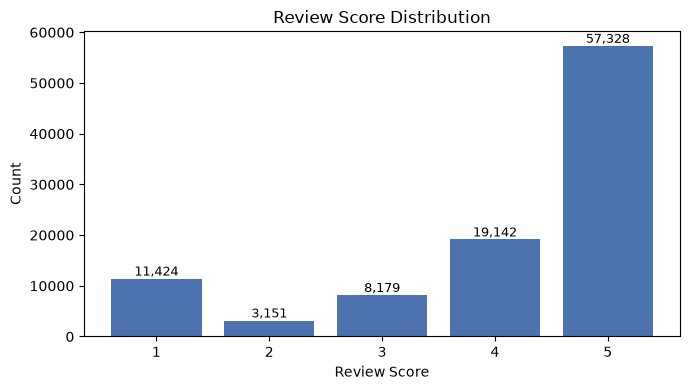

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_data = review_score_freq.dropna(subset=["review_score"]).sort_values("review_score")
bars = ax.bar(plot_data["review_score"].astype(int).astype(str), plot_data["count"], color="#4C72B0")
ax.set_xlabel("Review Score")
ax.set_ylabel("Count")
ax.set_title("Review Score Distribution")
for bar, count in zip(bars, plot_data["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Investigating the Non-Unique `review_id` Finding

Section 7 flagged `reviews.review_id` as not unique per row. This is investigated further below — as a data-quality/key finding to be considered during later joins, without assuming a cause. Duplicate records are **not** removed or modified here.

In [16]:
review_id_counts = dfs["reviews"]["review_id"].value_counts()
duplicated_review_ids = review_id_counts[review_id_counts > 1]
n_duplicate_review_id_values = int(len(duplicated_review_ids))

duplicate_review_id_mask = dfs["reviews"]["review_id"].duplicated(keep=False)
n_rows_affected_by_duplicate_review_id = int(duplicate_review_id_mask.sum())
n_orders_linked_to_duplicate_review_id = int(dfs["reviews"].loc[duplicate_review_id_mask, "order_id"].nunique())

print(f"Distinct review_id values that appear more than once: {n_duplicate_review_id_values:,}")
print(f"Total review rows affected by duplicated review_id: {n_rows_affected_by_duplicate_review_id:,}")
print(f"Distinct orders associated with duplicated review_id values: {n_orders_linked_to_duplicate_review_id:,}")

sample_duplicate_reviews = (
    dfs["reviews"][duplicate_review_id_mask]
    .sort_values("review_id")
    [["review_id", "order_id", "review_score", "review_creation_date", "review_answer_timestamp"]]
    .head(10)
)
display(sample_duplicate_reviews)

Distinct review_id values that appear more than once: 789
Total review rows affected by duplicated review_id: 1,603
Distinct orders associated with duplicated review_id values: 1,412


,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,2018-03-07 00:00:00,2018-03-20 18:08:23
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,2017-09-21 00:00:00,2017-09-26 03:27:47
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,2017-09-21 00:00:00,2017-09-26 03:27:47
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,2018-03-07 00:00:00,2018-03-08 03:00:53
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,2017-09-09 00:00:00,2017-09-13 09:52:44


## Delivery Delay Audit

Uses `orders.order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, and `order_estimated_delivery_date`. These are parsed into a working copy (`orders_dates`) — the raw `orders` DataFrame and the underlying CSV in `data/raw/` are never modified.

`delivery_delay_days = order_delivered_customer_date - order_estimated_delivery_date`, calculated only where both dates are available.

In [17]:
DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders_dates = dfs["orders"][["order_id"] + DATE_COLS].copy()
for col in DATE_COLS:
    orders_dates[col] = pd.to_datetime(orders_dates[col], errors="coerce")

display(orders_dates.dtypes.rename("dtype").to_frame())

,dtype
order_id,str
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]


In [18]:
has_both_dates = orders_dates["order_delivered_customer_date"].notna() & orders_dates["order_estimated_delivery_date"].notna()

orders_dates["delivery_delay_days"] = np.nan
orders_dates.loc[has_both_dates, "delivery_delay_days"] = (
    orders_dates.loc[has_both_dates, "order_delivered_customer_date"]
    - orders_dates.loc[has_both_dates, "order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delay_series = orders_dates["delivery_delay_days"]
missing_delay_count = int(delay_series.isna().sum())

delivery_delay_summary = {
    "count": int(delay_series.notna().sum()),
    "missing_count": missing_delay_count,
    "mean": round(delay_series.mean(), 3),
    "median": round(delay_series.median(), 3),
    "std": round(delay_series.std(), 3),
    "min": round(delay_series.min(), 3),
    "max": round(delay_series.max(), 3),
    "p10": round(delay_series.quantile(0.10), 3),
    "p25": round(delay_series.quantile(0.25), 3),
    "p75": round(delay_series.quantile(0.75), 3),
    "p90": round(delay_series.quantile(0.90), 3),
    "p95": round(delay_series.quantile(0.95), 3),
    "p99": round(delay_series.quantile(0.99), 3),
}
delivery_delay_summary_df = pd.DataFrame([delivery_delay_summary])

print(f"Orders with both required dates available (delay calculable): {int(has_both_dates.sum()):,}")
print(f"Orders missing one or both required dates (delay NOT calculable): {missing_delay_count:,}")
display(delivery_delay_summary_df)

Orders with both required dates available (delay calculable): 96,476
Orders missing one or both required dates (delay NOT calculable): 2,965


,count,missing_count,mean,median,std,min,max,p10,p25,p75,p90,p95,p99
0,96476,2965,-11.179,-11.949,10.186,-146.016,188.975,-21.286,-16.244,-6.39,-1.138,3.818,18.939


In [19]:
def categorize_delay(days):
    if pd.isna(days):
        return np.nan
    if days < 0:
        return "Early"
    elif days == 0:
        return "On Time"
    else:
        return "Late"


orders_dates["delivery_category"] = orders_dates["delivery_delay_days"].apply(categorize_delay)

valid_delay = orders_dates.dropna(subset=["delivery_delay_days"])

delivery_category_counts = valid_delay["delivery_category"].value_counts().reindex(["Early", "On Time", "Late"]).fillna(0).astype(int)
delivery_category_percentage = round(delivery_category_counts / len(valid_delay) * 100, 2)
delivery_category_table = pd.DataFrame({"count": delivery_category_counts, "percentage": delivery_category_percentage})
delivery_category_table.index.name = "delivery_category"

display(delivery_category_table.reset_index())

,delivery_category,count,percentage
0,Early,88649,91.89
1,On Time,0,0.00
2,Late,7827,8.11


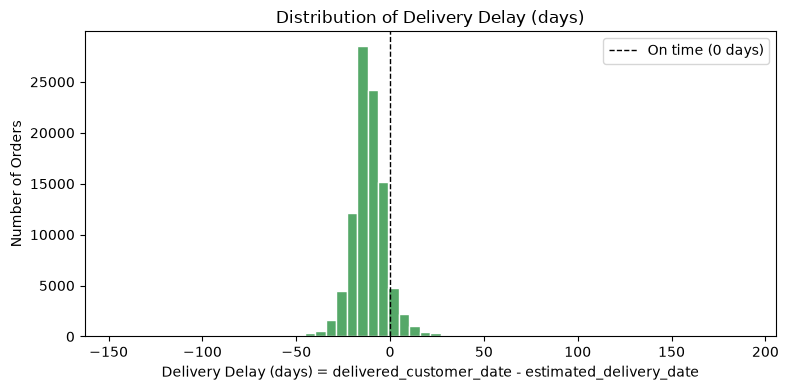

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_delay["delivery_delay_days"], bins=60, color="#55A868", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="On time (0 days)")
ax.set_xlabel("Delivery Delay (days) = delivered_customer_date - estimated_delivery_date")
ax.set_ylabel("Number of Orders")
ax.set_title("Distribution of Delivery Delay (days)")
ax.legend()
plt.tight_layout()
plt.show()

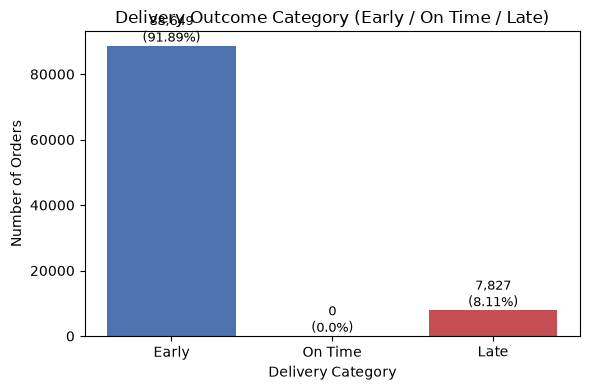

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
category_colors = {"Early": "#4C72B0", "On Time": "#55A868", "Late": "#C44E52"}
bars = ax.bar(
    delivery_category_table.index,
    delivery_category_table["count"],
    color=[category_colors[c] for c in delivery_category_table.index],
)
ax.set_xlabel("Delivery Category")
ax.set_ylabel("Number of Orders")
ax.set_title("Delivery Outcome Category (Early / On Time / Late)")
for bar, count, pct in zip(bars, delivery_category_table["count"], delivery_category_table["percentage"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}\n({pct}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Delivery Date Anomaly Checks

Checks for logically impossible date orderings within `orders_dates`. Rows are only evaluated where both relevant dates are present. No anomalies are silently removed here.

- **A**: `order_delivered_customer_date < order_purchase_timestamp`
- **B**: `order_approved_at < order_purchase_timestamp`
- **C**: `order_delivered_carrier_date < order_purchase_timestamp`
- **D**: `order_delivered_customer_date < order_delivered_carrier_date`

In [22]:
def audit_date_anomaly(df, earlier_col, later_col, label):
    """Flags rows where earlier_col ends up AFTER later_col, i.e. earlier_col > later_col
    (a logical impossibility), among rows where both dates are present."""
    relevant = df[earlier_col].notna() & df[later_col].notna()
    relevant_rows = int(relevant.sum())
    affected_mask = relevant & (df[earlier_col] < df[later_col])
    affected_rows = int(affected_mask.sum())
    affected_percentage = round(affected_rows / relevant_rows * 100, 4) if relevant_rows else 0.0

    if affected_rows == 0:
        status = "PASS"
    elif affected_percentage <= 1:
        status = "WARNING"
    else:
        status = "FAIL"

    return {
        "check": label,
        "relevant_rows": relevant_rows,
        "affected_rows": affected_rows,
        "affected_percentage": affected_percentage,
        "status": status,
    }


date_anomaly_checks = [
    audit_date_anomaly(orders_dates, "order_delivered_customer_date", "order_purchase_timestamp", "A: delivered_customer_date < purchase_timestamp"),
    audit_date_anomaly(orders_dates, "order_approved_at", "order_purchase_timestamp", "B: approved_at < purchase_timestamp"),
    audit_date_anomaly(orders_dates, "order_delivered_carrier_date", "order_purchase_timestamp", "C: delivered_carrier_date < purchase_timestamp"),
    audit_date_anomaly(orders_dates, "order_delivered_customer_date", "order_delivered_carrier_date", "D: delivered_customer_date < delivered_carrier_date"),
]

date_anomaly_df = pd.DataFrame(date_anomaly_checks)
display(date_anomaly_df)

,check,relevant_rows,affected_rows,affected_percentage,status
0,A: delivered_customer_date < purchase_timestamp,96476,0,0.0000,PASS
1,B: approved_at < purchase_timestamp,99281,0,0.0000,PASS
2,C: delivered_carrier_date < purchase_timestamp,97658,166,0.1700,WARNING
3,D: delivered_customer_date < delivered_carrier...,96475,23,0.0238,WARNING


## Extreme Delivery Delays (IQR Method)

Uses the standard IQR method to transparently flag unusually large positive delays among orders with a computable `delivery_delay_days`. Flagged orders are reported for review only — none are removed.

`upper_bound = Q3 + 1.5 * IQR`, where `IQR = Q3 - Q1`.

In [23]:
Q1 = valid_delay["delivery_delay_days"].quantile(0.25)
Q3 = valid_delay["delivery_delay_days"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

extreme_delay_mask = valid_delay["delivery_delay_days"] > upper_bound
n_extreme_delays = int(extreme_delay_mask.sum())
pct_extreme_delays = round(n_extreme_delays / len(valid_delay) * 100, 4)

print(f"Q1 (25th percentile): {Q1:.2f} days")
print(f"Q3 (75th percentile): {Q3:.2f} days")
print(f"IQR: {IQR:.2f} days")
print(f"Upper bound (Q3 + 1.5 * IQR): {upper_bound:.2f} days")
print(f"Number of extreme positive delays (> upper bound): {n_extreme_delays:,}")
print(f"Percentage of delivered orders (with computable delay) affected: {pct_extreme_delays}%")

extreme_delay_sample = (
    valid_delay.loc[extreme_delay_mask]
    .sort_values("delivery_delay_days", ascending=False)
    [["order_id", "order_purchase_timestamp", "order_estimated_delivery_date", "order_delivered_customer_date", "delivery_delay_days"]]
    .head(10)
)
display(extreme_delay_sample)

Q1 (25th percentile): -16.24 days
Q3 (75th percentile): -6.39 days
IQR: 9.85 days
Upper bound (Q3 + 1.5 * IQR): 8.39 days
Number of extreme positive delays (> upper bound): 2,830
Percentage of delivered orders (with computable delay) affected: 2.9334%


,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-03-15,2018-09-19 23:24:07,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-22,2017-09-19 14:36:39,181.608785
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-01-19,2018-07-13 20:51:31,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-04-05,2017-09-19 17:00:07,167.708414
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-04-06,2017-09-19 14:00:04,166.583380
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-04-07,2017-09-19 15:12:50,165.633912
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-04-10,2017-09-19 17:14:25,162.718345
40847,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:11,2017-06-26,2017-12-04 18:36:29,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-04-11,2017-09-19 14:38:21,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-04-13,2017-09-19 14:38:18,159.609931


## Week 1 Audit Findings

Consolidated below, computed directly from the results calculated above (no invented findings).

In [24]:
audit_findings = []

audit_findings.append({
    "finding": "customers.customer_id is order-scoped, not a persistent customer identifier",
    "severity": "Low",
    "evidence": (
        f"customer_id is unique in both customers ({n_customers_rows:,} rows) and orders (max occurrences per value = "
        f"{max_orders_per_customer_id}), a genuine 1:1 relationship at that grain. The real repeat-customer identifier is "
        f"customer_unique_id: only {n_customer_unique_ids:,} distinct real customers across {n_customers_rows:,} customer rows, "
        f"with up to {max_orders_per_customer} orders for a single customer and {customers_with_multiple_orders:,} customers "
        f"placing more than 1 order."
    ),
    "implication": "Any later RFM/CLV work must key off customer_unique_id, not customer_id, to correctly count each real customer's orders; this is a data-semantics clarification, not a data-quality defect.",
})

audit_findings.append({
    "finding": "reviews.review_id is not unique",
    "severity": "Medium",
    "evidence": (
        f"{n_duplicate_review_id_values:,} review_id values are duplicated, affecting "
        f"{n_rows_affected_by_duplicate_review_id:,} rows across {n_orders_linked_to_duplicate_review_id:,} distinct orders."
    ),
    "implication": "review_id cannot be safely used as a standalone join key; joins involving reviews should key off order_id and explicitly account for duplicates.",
})

geoloc_row = key_checks_df.loc[key_checks_df["table"] == "geolocation"].iloc[0]
audit_findings.append({
    "finding": "geolocation ZIP-code prefix is not unique",
    "severity": "Low",
    "evidence": f"{int(geoloc_row['n_rows']):,} geolocation rows collapse to only {int(geoloc_row['n_unique_combinations']):,} unique ZIP-code prefixes.",
    "implication": "Joining customers/sellers to geolocation on ZIP prefix is many-to-many; a representative coordinate per prefix must be chosen before any spatial analysis.",
})

missing_delivery_dates = int(orders_dates["order_delivered_customer_date"].isna().sum())
audit_findings.append({
    "finding": "Missing delivery dates",
    "severity": "Medium" if missing_delivery_dates > 0 else "None",
    "evidence": (
        f"{missing_delivery_dates:,} orders ({round(missing_delivery_dates / len(orders_dates) * 100, 2)}%) have no "
        f"order_delivered_customer_date; delivery_delay_days could not be calculated for {missing_delay_count:,} orders overall."
    ),
    "implication": "These orders (e.g. cancelled/undelivered) must be excluded from delivery-delay analysis, not imputed.",
})

audit_findings.append({
    "finding": "Invalid review scores outside the 1-5 range",
    "severity": "None" if invalid_score_count == 0 else "High",
    "evidence": f"{invalid_score_count} review_score value(s) found outside the expected 1-5 range.",
    "implication": "review_score can be used as-is." if invalid_score_count == 0 else "Invalid scores must be cleaned or investigated before use in any modeling.",
})

n_suspicious_date_rows = int(date_anomaly_df["affected_rows"].sum())
date_anomaly_evidence = "; ".join(
    f"{row.check.split(':')[0]}: {row.affected_rows:,} rows ({row.affected_percentage}%, {row.status})"
    for row in date_anomaly_df.itertuples()
)
audit_findings.append({
    "finding": "Suspicious delivery-date sequences (checks A-D)",
    "severity": "None" if n_suspicious_date_rows == 0 else "Medium",
    "evidence": date_anomaly_evidence,
    "implication": "No logically impossible date orderings observed." if n_suspicious_date_rows == 0 else "Affected orders have internally inconsistent timelines and must be handled explicitly before delivery-time modeling.",
})

audit_findings.append({
    "finding": "Extreme positive delivery delays (IQR method)",
    "severity": "Medium" if n_extreme_delays > 0 else "None",
    "evidence": f"{n_extreme_delays:,} orders ({pct_extreme_delays}%) have delivery_delay_days above the IQR upper bound of {upper_bound:.1f} days.",
    "implication": "Candidate outliers for later review; not deleted, since they may reflect genuine operational failures relevant to CLV/segmentation.",
})

ref_issues = referential_integrity_audit[referential_integrity_audit["status"] != "PASS"]
if len(ref_issues) == 0:
    ref_evidence = "All 9 checked relationships passed with 0% unmatched child rows."
    ref_severity = "None"
else:
    ref_evidence = "; ".join(f"{r.relationship}: {r.unmatched_percentage}% unmatched ({r.status})" for r in ref_issues.itertuples())
    ref_severity = "High" if (ref_issues["status"] == "FAIL").any() else "Medium"
audit_findings.append({
    "finding": "Referential integrity across the 9 tables",
    "severity": ref_severity,
    "evidence": ref_evidence,
    "implication": "The checked keys can be safely joined without silent record loss." if len(ref_issues) == 0 else "Joins on the affected keys will drop or orphan rows; the join strategy (inner vs. left) must be chosen deliberately.",
})

audit_findings_df = pd.DataFrame(audit_findings)[["finding", "severity", "evidence", "implication"]]
display(audit_findings_df)

,finding,severity,evidence,implication
0,"customers.customer_id is order-scoped, not a p...",Low,"customer_id is unique in both customers (99,44...",Any later RFM/CLV work must key off customer_u...
1,reviews.review_id is not unique,Medium,"789 review_id values are duplicated, affecting...",review_id cannot be safely used as a standalon...
2,geolocation ZIP-code prefix is not unique,Low,"1,000,163 geolocation rows collapse to only 19...",Joining customers/sellers to geolocation on ZI...
3,Missing delivery dates,Medium,"2,965 orders (2.98%) have no order_delivered_c...",These orders (e.g. cancelled/undelivered) must...
4,Invalid review scores outside the 1-5 range,None,0 review_score value(s) found outside the expe...,review_score can be used as-is.
5,Suspicious delivery-date sequences (checks A-D),Medium,"A: 0 rows (0.0%, PASS); B: 0 rows (0.0%, PASS)...",Affected orders have internally inconsistent t...
6,Extreme positive delivery delays (IQR method),Medium,"2,830 orders (2.9334%) have delivery_delay_day...",Candidate outliers for later review; not delet...
7,Referential integrity across the 9 tables,Medium,products.product_category_name -> category_tra...,Joins on the affected keys will drop or orphan...


## ER Relationship Specification

This section turns the referential-integrity audit results computed above (`referential_integrity_audit`, `key_checks_df`, `key_profile`) into a clean relationship specification for the ER map (R1), covering **10 relationships**: the 9 direct table-to-table FK checks, plus the `customers.customer_unique_id -> orders` relationship added by the Cardinality Deep-Dive above (the genuine 1:many "real customer places many orders" relationship). It reuses the **same audit results already calculated** in this notebook — no new checks beyond that one correction, no invented keys, and the existing **Verified / Inferred / Flagged for audit** terminology from Sections 7–8 is carried through.

**Verification status legend used below:**

- **Verified** — key/relationship confirmed unique and/or 0% unmatched child rows
- **Verified (Warning)** — key itself is verified, but the referential-integrity check found a small (>0%, ≤1%) share of unmatched child rows
- **Inferred** — relationship holds structurally (matching names/semantics) but the parent side is not a unique key (e.g. ZIP-code prefix)
- **Inferred (Warning)** — inferred relationship with a small share of unmatched child rows on top
- **Flagged for audit** — key found to be non-unique where uniqueness was expected (`reviews.review_id`)

In [25]:
er_relationship_notes = {
    ("customers", "orders", "customer_id"): (
        "Genuinely 1:1 at the order-scoped grain: customer_id is a new surrogate value generated per order, even for "
        "repeat customers (confirmed in the Cardinality Deep-Dive above). See the customer_unique_id relationship "
        "below for the real one-customer-to-many-orders relationship."
    ),
    ("customers", "orders", "customer_unique_id"): (
        f"The REAL customer-to-order relationship (Cardinality Deep-Dive above): customers deduplicated to "
        f"{n_customer_unique_ids:,} distinct real customers, joined to orders via customer_id. Up to "
        f"{max_orders_per_customer} orders for a single customer; {customers_with_multiple_orders:,} customers "
        f"placed more than 1 order. Use customer_unique_id, not customer_id, for any future RFM/CLV work."
    ),
    ("orders", "order_items", "order_id"): "One order can contain multiple line items.",
    ("orders", "payments", "order_id"): "One order can have multiple payment rows (e.g. split/installment payments).",
    ("orders", "reviews", "order_id"): (
        f"order_id join itself is clean. Separately, reviews.review_id is Flagged for audit: "
        f"{n_duplicate_review_id_values:,} duplicated review_id values affecting {n_rows_affected_by_duplicate_review_id:,} rows "
        f"across {n_orders_linked_to_duplicate_review_id:,} orders — do not treat review_id as a unique join key downstream."
    ),
    ("products", "order_items", "product_id"): "One product can appear in many order line items.",
    ("sellers", "order_items", "seller_id"): "One seller can fulfill many order line items.",
    ("category_translation", "products", "product_category_name"): (
        "Text-based join on category name (not a surrogate id). category_translation.product_category_name is the "
        "verified '1' side (71/71 unique); products.product_category_name is the 'many' side. A small number of "
        "products reference a category name absent from the translation table."
    ),
    ("geolocation", "customers", "customer_zip_code_prefix"): (
        "ZIP-prefix join is many-to-many because geolocation has no unique key (Inferred, per Sections 7-8); "
        "a small share of customer ZIP prefixes have no match in geolocation."
    ),
    ("geolocation", "sellers", "seller_zip_code_prefix"): (
        "ZIP-prefix join is many-to-many because geolocation has no unique key (Inferred, per Sections 7-8); "
        "a small share of seller ZIP prefixes have no match in geolocation."
    ),
}


def er_verification_status(row):
    is_zip_join = row["parent_table"] == "geolocation"
    if row["status"] == "PASS":
        return "Inferred" if is_zip_join else "Verified"
    if row["status"] == "WARNING":
        return "Inferred (Warning)" if is_zip_join else "Verified (Warning)"
    return "Flagged for audit"


def er_cardinality_notation(row):
    if row["cardinality"] == "1:1":
        return f"{row['parent_table']} (1) --- (1) {row['child_table']}"
    if row["cardinality"] == "1:many":
        return f"{row['parent_table']} (1) --- (many) {row['child_table']}"
    if row["cardinality"] == "many:many":
        return f"{row['parent_table']} (many) --- (many) {row['child_table']}"
    return f"{row['parent_table']} (many) --- (1) {row['child_table']}"


er_relationship_spec = referential_integrity_audit.copy()
er_relationship_spec["relationship_cardinality"] = er_relationship_spec.apply(er_cardinality_notation, axis=1)
er_relationship_spec["verification_status"] = er_relationship_spec.apply(er_verification_status, axis=1)
er_relationship_spec["notes"] = er_relationship_spec.apply(
    lambda r: (
        f"{er_relationship_notes.get((r['parent_table'], r['child_table'], r['child_key']), '')} "
        f"[{r['unmatched_child_rows']} unmatched of {r['child_rows_checked']:,} checked = {r['unmatched_percentage']}%]"
    ).strip(),
    axis=1,
)

er_relationship_spec = er_relationship_spec[
    ["parent_table", "parent_key", "child_table", "child_key", "relationship_cardinality", "verification_status", "notes"]
]

display(er_relationship_spec)

,parent_table,parent_key,child_table,child_key,relationship_cardinality,verification_status,notes
0,customers,customer_id,orders,customer_id,customers (1) --- (1) orders,Verified,Genuinely 1:1 at the order-scoped grain: custo...
1,customers,customer_unique_id,orders,customer_unique_id,customers (1) --- (many) orders,Verified,The REAL customer-to-order relationship (Cardi...
2,orders,order_id,order_items,order_id,orders (1) --- (many) order_items,Verified,One order can contain multiple line items. [0 ...
3,orders,order_id,payments,order_id,orders (1) --- (many) payments,Verified,One order can have multiple payment rows (e.g....
4,orders,order_id,reviews,order_id,orders (1) --- (many) reviews,Verified,"order_id join itself is clean. Separately, rev..."
5,products,product_id,order_items,product_id,products (1) --- (many) order_items,Verified,One product can appear in many order line item...
6,sellers,seller_id,order_items,seller_id,sellers (1) --- (many) order_items,Verified,One seller can fulfill many order line items. ...
7,category_translation,product_category_name,products,product_category_name,category_translation (1) --- (many) products,Verified (Warning),Text-based join on category name (not a surrog...
8,geolocation,geolocation_zip_code_prefix,customers,customer_zip_code_prefix,geolocation (many) --- (many) customers,Inferred (Warning),ZIP-prefix join is many-to-many because geoloc...
9,geolocation,geolocation_zip_code_prefix,sellers,seller_zip_code_prefix,geolocation (many) --- (many) sellers,Inferred (Warning),ZIP-prefix join is many-to-many because geoloc...


### Direction Check: `products` ↔ `category_translation`

The relationship string reads `products.product_category_name -> category_translation.product_category_name` (standard "child -> parent" FK notation), which could be misread as suggesting `products` is the "1" side. It is not. The cardinality is derived from actual key-uniqueness checks already computed in Sections 7–9, confirmed again here:

In [26]:
category_translation_unique = bool(dfs["category_translation"]["product_category_name"].dropna().is_unique)
products_category_has_duplicates = bool(dfs["products"]["product_category_name"].dropna().duplicated().any())

print(f"category_translation.product_category_name is unique per row: {category_translation_unique}  <- this is the '1' side")
print(f"products.product_category_name has duplicate values: {products_category_has_duplicates}  <- this is the 'many' side")
print()
print("Confirmed direction: category_translation (1) --- (many) products. Not reversed.")

category_translation.product_category_name is unique per row: True  <- this is the '1' side
products.product_category_name has duplicate values: True  <- this is the 'many' side

Confirmed direction: category_translation (1) --- (many) products. Not reversed.


## Next Steps

R1 (the full 9-table ER map) is now complete: the relationship specification above, plus the editable diagram at `docs/er_diagram/olist_er_diagram.drawio` and its PNG export at `docs/er_diagram/olist_er_diagram.png`.

The remaining Week 1 work is:

1. Create the data dictionary / data charter
2. Document the dataset licensing / source information
3. Perform final Week 1 QA

These items are not implemented yet and will be addressed in the next step.